<a href="https://colab.research.google.com/github/kukanmani06/Machine_Learning/blob/main/K_Means_Clustering_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Import Librar

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
mall_customers = pd.read_csv("https://raw.githubusercontent.com/ammishra08/MachineLearning/refs/heads/master/Datasets/Mall_Customers.csv")

In [4]:
mall_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
mall_customers.shape

(200, 5)

In [6]:
mall_customers.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
mall_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
mall_customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


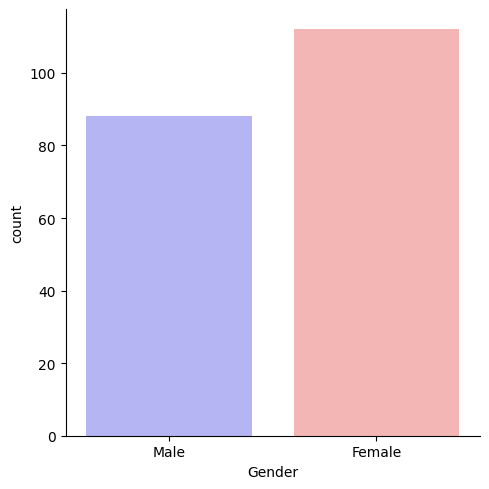

In [9]:
sns.catplot(x="Gender",kind="count",data=mall_customers,palette='bwr')
plt.show()

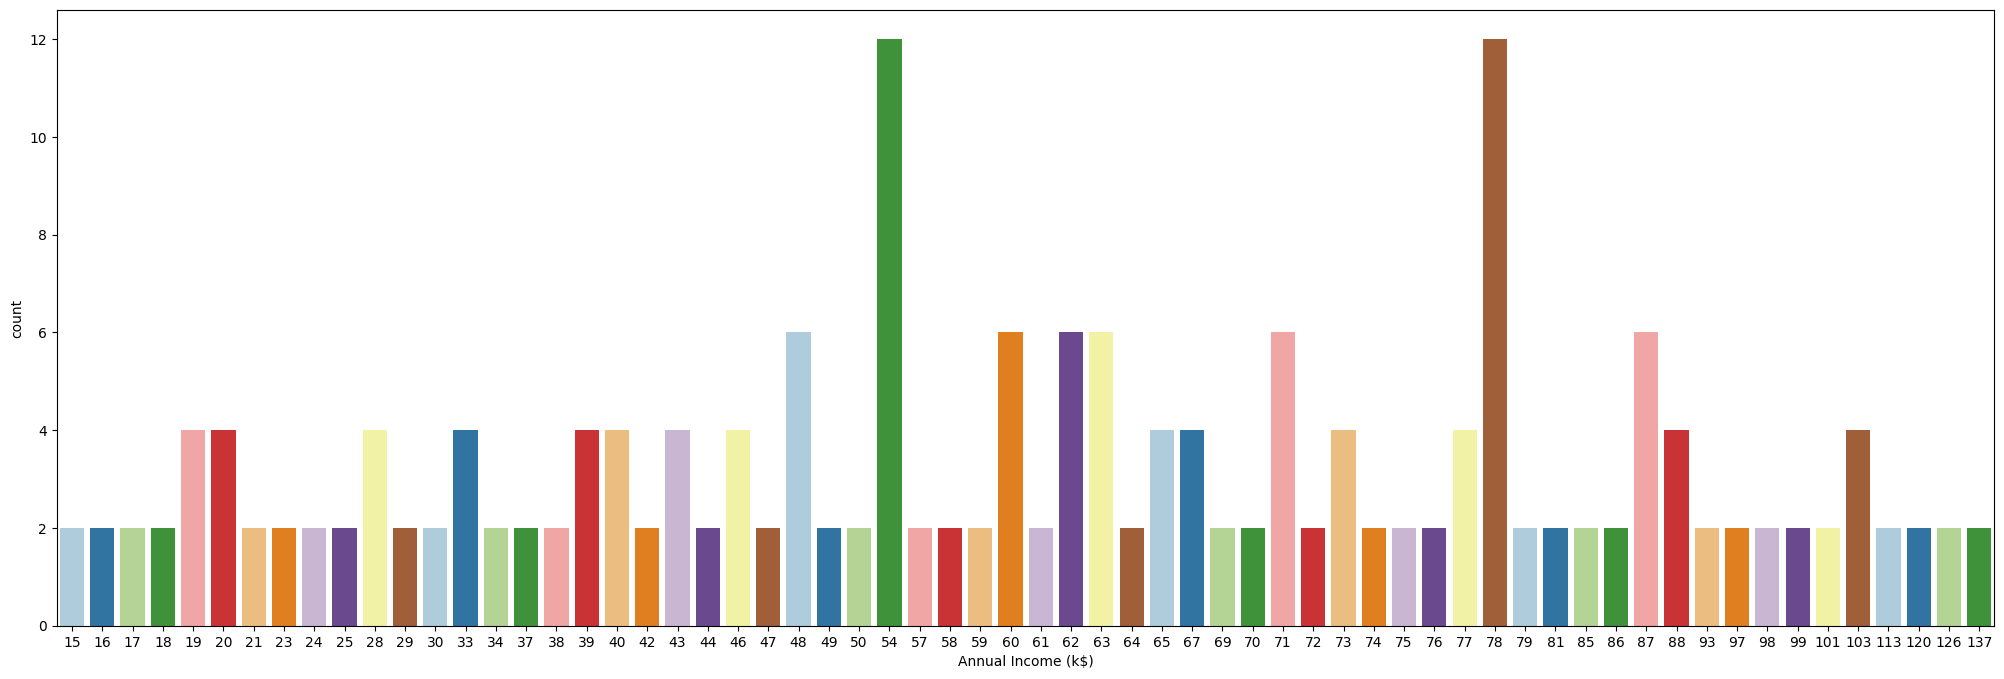

In [10]:
plt.figure(figsize=(25,8))
sns.countplot(x=mall_customers['Annual Income (k$)'],palette='Paired')
plt.show()

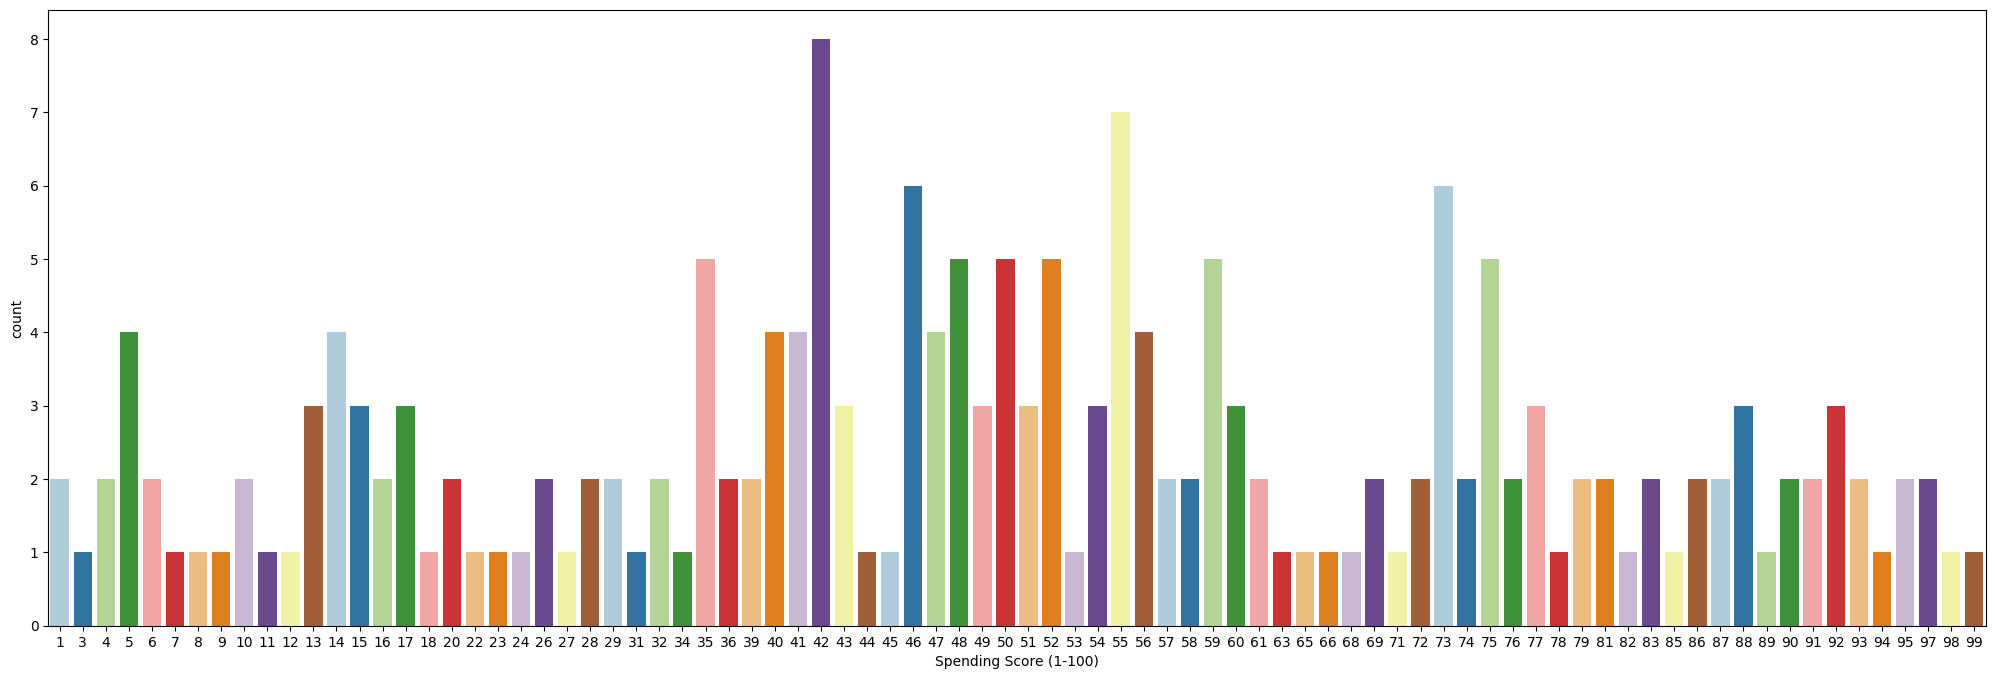

In [11]:
plt.figure(figsize=(25,8))
sns.countplot(x=mall_customers['Spending Score (1-100)'],palette='Paired')
plt.show()

In [12]:
x=mall_customers.loc[:,['Annual Income (k$)','Spending Score (1-100)']]

In [13]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,15):
  kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=2)
  kmeans.fit(x) # Changed X to x
  wcss.append(kmeans.inertia_)

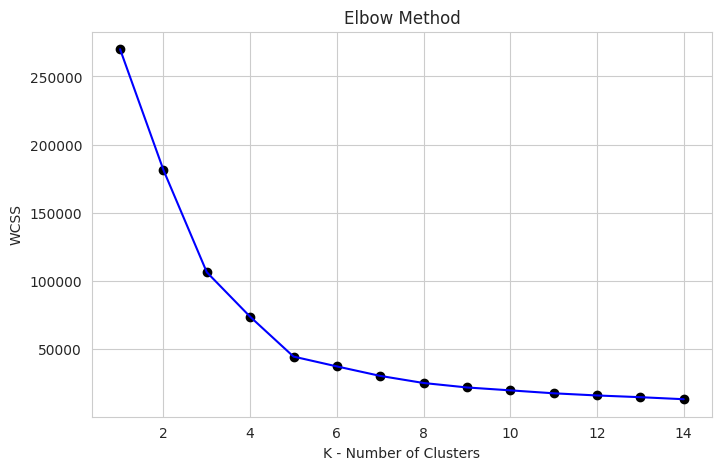

In [14]:
sns.set_style('whitegrid')
plt.figure(figsize = (8,5))
plt.plot(range(1,15), wcss, color = 'b')
plt.scatter(range(1,15), wcss, color = 'k')
plt.xlabel("K - Number of Clusters")
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [15]:
!pip install kneed

In [16]:
from kneed import KneeLocator
knee = KneeLocator(range(1,15), wcss, curve='convex', direction='decreasing')
print(knee.elbow)

5


In [17]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 2)

In [18]:
kmeans.fit(x)

KMeans(n_clusters=5, n_init=10, random_state=2)

In [19]:
# predicted clusters for each sample X
y_clusters = kmeans.predict(x)
y_clusters

array([2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 0,
       2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 3, 0, 3, 1, 3, 1, 3,
       0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3], dtype=int32)

In [20]:
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636]])

In [21]:
x['Cluster'] = y_clusters

In [22]:
x.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,2
1,15,81,4
2,16,6,2
3,16,77,4
4,17,40,2


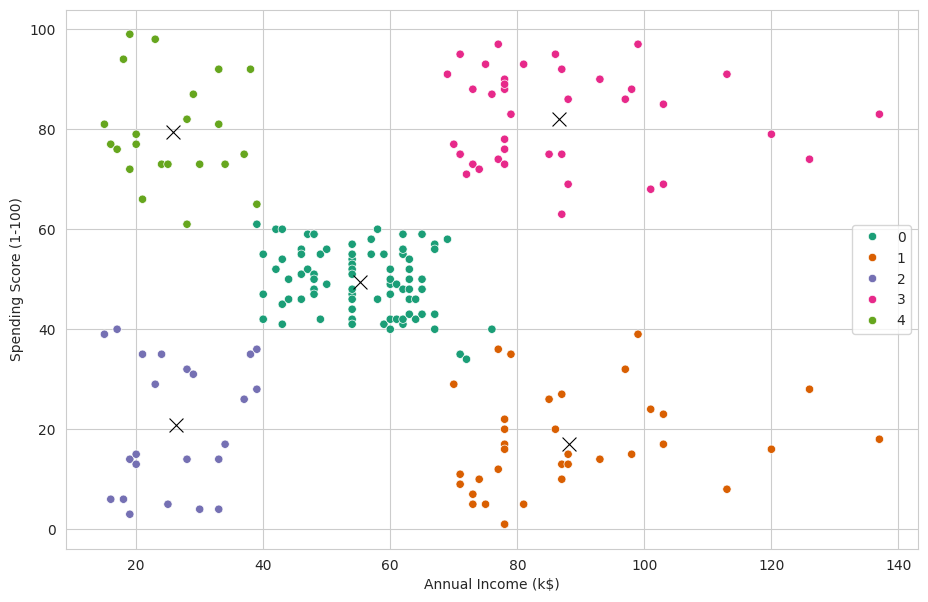

In [23]:
plt.figure(figsize = (11,7))
sns.scatterplot(x = x['Annual Income (k$)'], y = x['Spending Score (1-100)'], hue = x['Cluster'], palette='Dark2')
sns.scatterplot(x = kmeans.cluster_centers_[:, 0], y = kmeans.cluster_centers_[:, 1], color = 'black', s = 100, marker='x')
plt.show()

Cluster Evaluation

In [24]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x, y_clusters)
print(score)

0.5552901983515259


In [25]:
from seaborn.matrix import dendrogram
import scipy.cluster.hierarchy as sch

In [26]:
x=mall_customers[['Annual Income (k$)','Spending Score (1-100)']]

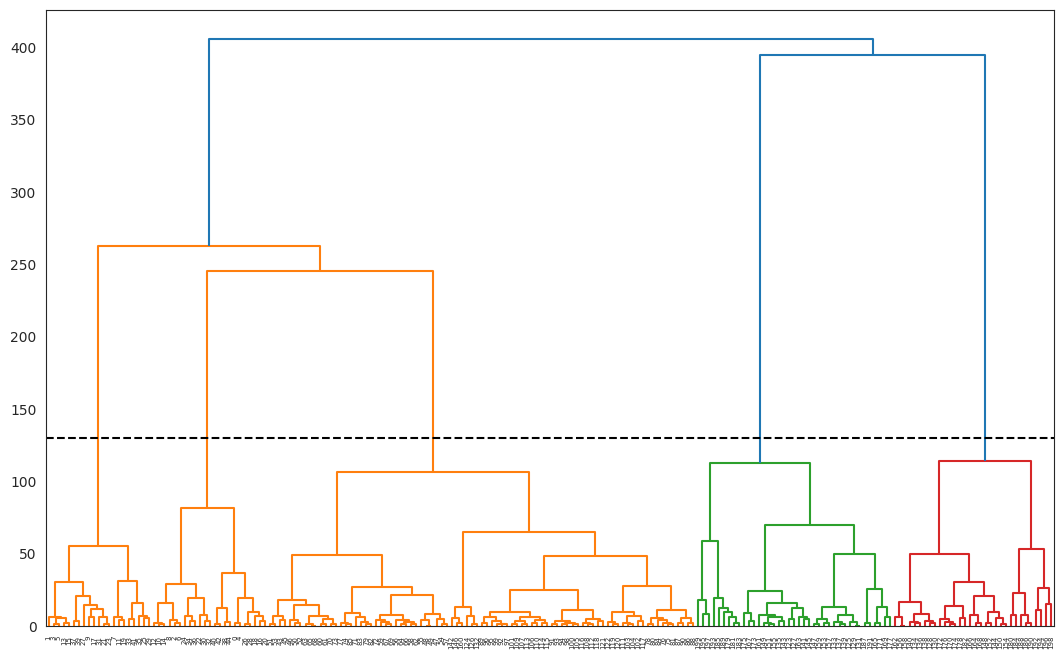

In [27]:
sns.set_style('white')
plt.figure(figsize = (13,8))
sch.dendrogram(sch.linkage(x, method='ward'))
plt.axhline(130, linestyle = '--', color = 'black')
plt.show()

In [28]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
hc.fit(x)

AgglomerativeClustering(n_clusters=5)

In [29]:
y_clusters = hc.fit_predict(x)
y_clusters

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [30]:
x['Cluster'] = y_clusters

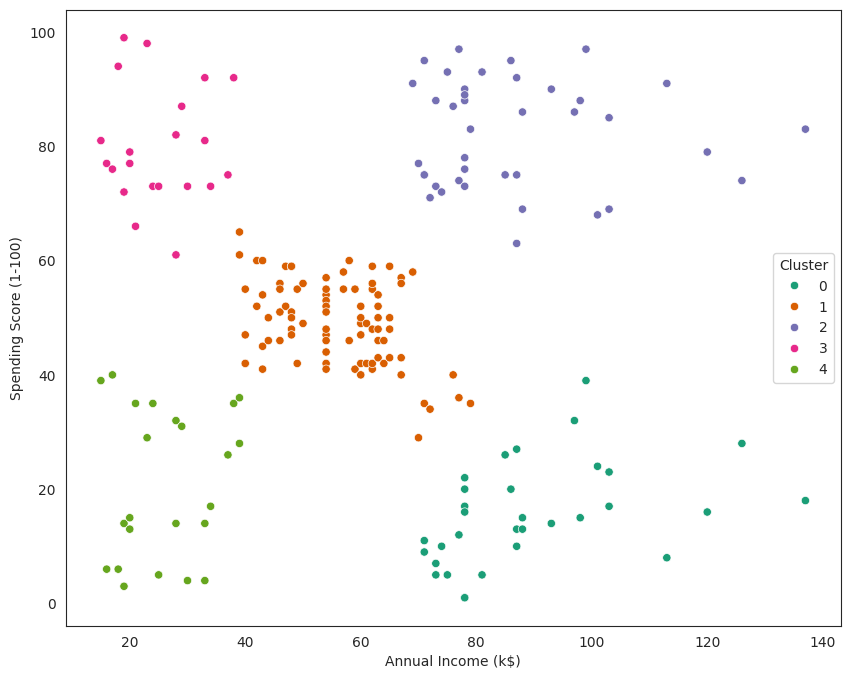

In [31]:
plt.figure(figsize = (10, 8))
sns.scatterplot(x = x['Annual Income (k$)'], y = x['Spending Score (1-100)'], hue = x['Cluster'], palette='Dark2')
plt.show()

In [33]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x, y_clusters)
print(score)

0.5537060749833154
